In [27]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from PIL import Image
import glob
import shutil

In [28]:
#data exploration
csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
count=0
totalcount=0
for paths in csv_path:
    totalcount+=1
    if paths.endswith('.jpg'):
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".jpg",".csv"))
        if not os.path.isfile(imgpth):
            count+=1
            print(paths)
print("img with no csv=",count)
            
        


1665-M-014Y1(1).jpg
img with no csv= 1


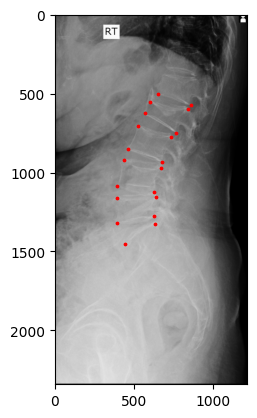

   685.9785   381.5689  902.6589   413.2783  0
0  650.0413   501.0074  863.5508   570.7679  0
1  603.5342   554.9133  844.5252   595.0784  0
2  568.6540   624.6738  767.3658   746.2263  0
3  527.4319   703.9471  735.6565   772.6507  0
4  461.8993   851.9240  676.4658   933.3113  0
5  435.4748   921.6846  671.1808   973.4764  0
6  395.3097  1083.4020  625.7308  1122.5100  0
7  391.0818  1160.5620  642.6425  1156.3340  0
8  395.3097  1322.2790  629.9587  1274.7150  0
9  446.0446  1451.2300  633.1296  1323.3360  0


In [29]:
#data exploration on images
imagedir='/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA'
csvdir=imagedir
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        print(info)
        count+=1
        if count>0:
            break

In [30]:
#data cleaning
csv_path=os.listdir("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA")
dst="/kaggle/working/clean_data/"
csvdst = "/kaggle/working/clean_data/csv"
imgdst="/kaggle/working/clean_data/img"
os.makedirs(dst, exist_ok=True)
os.makedirs(csvdst, exist_ok=True)
os.makedirs(imgdst, exist_ok=True)
count=0
totalcount=0
for paths in csv_path:
    
    if paths.endswith('.csv'):
        totalcount+=1
        act_path=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths)
        #dat=pd.read_csv(act_path)
        # pd.set_option('display.max_rows', None)
        # pd.set_option('display.max_columns', None)
        # print(dat)
        imgpth=os.path.join("/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/LA",paths.replace(".csv",".jpg"))
        if os.path.isfile(imgpth):
            shutil.copy(act_path, csvdst)
            shutil.copy(imgpth, imgdst)
        else:
            print(paths,'skipped')
print('done')
            
        


1674-F-050Y1(1).csv skipped
1669-M-048Y1(1).csv skipped
1667-F-065Y1(1).csv skipped
done


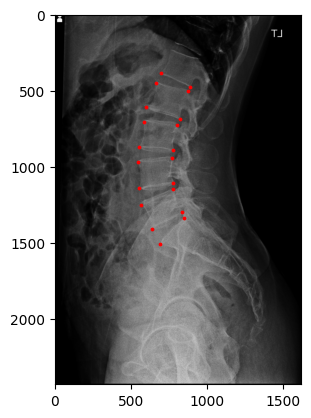

In [31]:
#data exploration on images after cleaning
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/working/clean_data/csv"
count =0
for fname in os.listdir(imagedir):
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        csvname=name+'.csv'
        csvpth=os.path.join(csvdir,csvname)
        info=pd.read_csv(csvpth)

        fig,ax=plt.subplots()
        ax.imshow(img)
        ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
        ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break


/tmp/ipykernel_58/1065733884.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)


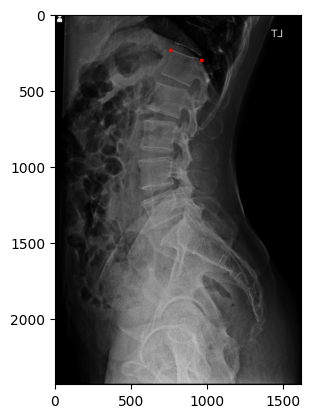

In [32]:
#data on excel
imagedir='/kaggle/working/clean_data/img'
csvdir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"

count =0
info=pd.read_excel(csvdir,sheet_name='Pos_LA',index_col='filename')
for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        img=Image.open(os.path.join(imagedir,fname))
        name=os.path.splitext(fname)[0]
        fig,ax=plt.subplots()
        ax.imshow(img)
        if name in info.index:
            row_data = info.loc[name]
        #use this:
        ax.scatter(row_data.iloc[3],row_data.iloc[4],c='red',s=3)
        #avoid this:
        ax.scatter(info.loc[name][5],info.loc[name][6],c='red',s=3)
        
        #ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
        plt.show()
        # print(info.iloc[:,2],info.iloc[:,3])
        count+=1
        if count>0:
            break

Index(['lumbar', 'diagnosis_number', '   ', 'gender', 'Unnamed: 5',
       'Count of diagnosis_title', 'Column Labels', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')
Retrolisthesis


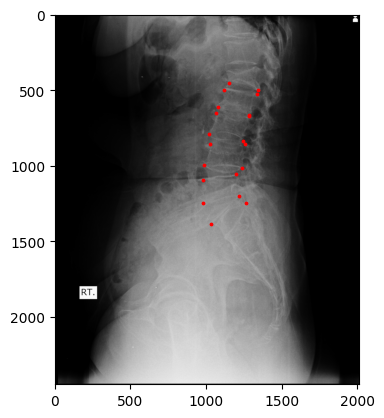

Anterolisthesis


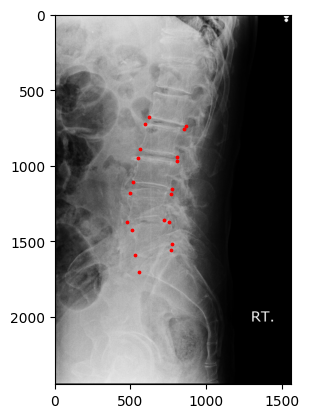

note: no left or right Laterolisthesis as dataset is dealing with only sagittal view


In [33]:
#data on excel according to diagnosis
imagedir='/kaggle/working/clean_data/img'
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
csvdir="/kaggle/working/clean_data/csv"
count1,count2,count3,count4=0,0,0,0
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis',index_col='filename')
print(diaginfo.columns)
for fname in os.listdir(imagedir):
    
    
    if fname.endswith('.jpg'):
        name=os.path.splitext(fname)[0]
        if name in diaginfo.index:
            current_diagnosis = diaginfo.loc[name, 'diagnosis_number']
            
                
            if current_diagnosis == 3 and count3 == 0:
                print("Anterolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count3 += 1
                
            elif current_diagnosis == 4 and count4 == 0:
                print("Retrolisthesis")
                img = Image.open(os.path.join(imagedir, fname))
                csvname=name+'.csv'
                csvpth=os.path.join(csvdir,csvname)
                info=pd.read_csv(csvpth)
                fig, ax = plt.subplots()
                ax.imshow(img)
                ax.scatter(info.iloc[:,2],info.iloc[:,3],c='red',s=3)
                ax.scatter(info.iloc[:,0],info.iloc[:,1],c='red',s=3)
                plt.show()
                count4 += 1
            
            
            if count3 > 0 and count4 > 0:
                break
print("note: no left or right Laterolisthesis as dataset is dealing with only sagittal view")

In [34]:
import statistics
imagedir='/kaggle/working/clean_data/img'
h,w=[],[]
for fname in os.listdir(imagedir):
    with Image.open(os.path.join(imagedir,fname)) as img:
        width, height = img.size
        h.append(height)
        w.append(width)
print("height means and std:",statistics.mean(h),statistics.stdev(h))
print("width means and std:",statistics.mean(w),statistics.stdev(w))        

height means and std: 2490.55897862892 220.75834935727764
width means and std: 1812.5736885928393 383.02430512850987


In [35]:
#data preperation

from pandas import DataFrame
xldir="/kaggle/input/datasets/lavanyanigam/lumbar-spine-dataset/KIOM2022_dataset_report.xlsx"
diaginfo=pd.read_excel(xldir,sheet_name='diagnosis')
csvinfo=pd.read_excel(xldir,sheet_name='Pos_LA')
xldst = "/kaggle/working/clean_data/excel"
os.makedirs(xldst, exist_ok=True)

diaginfo['diagnosis_no'] = diaginfo['diagnosis_number'].apply(lambda x: x if x in [3, 4] else 0)
diag_subset = diaginfo[['filename', 'diagnosis_no']]
df = pd.merge(csvinfo, diag_subset, on='filename', how='left')
df['diagnosis_no'] = df['diagnosis_no'].fillna(0).astype(int)
print(df.columns)
df['gender'] = df['gender'].apply(lambda x: 0 if x == 'M' else 1)


output_path = os.path.join(xldst, 'test.xlsx') 
df.to_excel(output_path, sheet_name='sheet1', index=False)

print('merged diagnosis and points positions successfully')
        

Index(['filename', 'gender', 'age', 'type', 'L1a_1c', 'L1a_1r', 'L1a_2c',
       'L1a_2r', 'L1b_1c', 'L1b_1r', 'L1b_2c', 'L1b_2r', 'L2a_1c', 'L2a_1r',
       'L2a_2c', 'L2a_2r', 'L2b_1c', 'L2b_1r', 'L2b_2c', 'L2b_2r', 'L3a_1c',
       'L3a_1r', 'L3a_2c', 'L3a_2r', 'L3b_1c', 'L3b_1r', 'L3b_2c', 'L3b_2r',
       'L4a_1c', 'L4a_1r', 'L4a_2c', 'L4a_2r', 'L4b_1c', 'L4b_1r', 'L4b_2c',
       'L4b_2r', 'L5a_1c', 'L5a_1r', 'L5a_2c', 'L5a_2r', 'L5b_1c', 'L5b_1r',
       'L5b_2c', 'L5b_2r', 'S1a_1c', 'S1a_1r', 'S1a_2c', 'S1a_2r', 'L1b_d',
       'L2b_d', 'L3b_d', 'L4b_d', 'L5b_d', 'diagnosis_no'],
      dtype='object')
merged diagnosis and points positions successfully


In [36]:

def predict_acc_to_leaves(no_of_leaves,train_X, val_X, train_y, val_y):
    rf_model = RandomForestRegressor(max_leaf_nodes=no_of_leaves,random_state=1)
    rf_model.fit(train_X, train_y)
    rf_val_predictions = rf_model.predict(val_X)
    rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)
    return rf_val_mae

In [37]:
#check best hyperparameters
#on raw coordinates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


xldst = "/kaggle/working/clean_data/excel/test.xlsx"
spine_data = pd.read_excel(xldst,sheet_name='sheet1', index_col='filename')
y = spine_data.diagnosis_no
# print(spine_data.columns)




# Select columns corresponding to features, and preview the data
X_before = spine_data[['gender', 'age', 'type', 'L1a_1c', 'L1a_1r', 'L1a_2c', 'L1a_2r',
       'L1b_1c', 'L1b_1r', 'L1b_2c', 'L1b_2r', 'L2a_1c', 'L2a_1r', 'L2a_2c',
       'L2a_2r', 'L2b_1c', 'L2b_1r', 'L2b_2c', 'L2b_2r', 'L3a_1c', 'L3a_1r',
       'L3a_2c', 'L3a_2r', 'L3b_1c', 'L3b_1r', 'L3b_2c', 'L3b_2r', 'L4a_1c',
       'L4a_1r', 'L4a_2c', 'L4a_2r', 'L4b_1c', 'L4b_1r', 'L4b_2c', 'L4b_2r',
       'L5a_1c', 'L5a_1r', 'L5a_2c', 'L5a_2r', 'L5b_1c', 'L5b_1r', 'L5b_2c',
       'L5b_2r', 'S1a_1c', 'S1a_1r', 'S1a_2c', 'S1a_2r']]
X=pd.get_dummies(X_before, columns=[ 'type'], drop_first=True) 

# Split into validation and training data
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# Define a random forest model
# rf_model = RandomForestRegressor(random_state=1)
# rf_model.fit(train_X, train_y)
# rf_val_predictions = rf_model.predict(val_X)
# rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)

no_of_leaves=[5,10,20,50,100,500,1000,100000]
best=999999999999999
no=0
for n in no_of_leaves:
    x=predict_acc_to_leaves(n,train_X, val_X, train_y, val_y)
    if x<best:
        best=x
        no=n

print("Validation MAE for Random Forest Model:",best,"no of leaves:",no)

Validation MAE for Random Forest Model: 1.2008429077740375 no of leaves: 500


In [39]:
#use the best hyperparameters on full training set

xldst = "/kaggle/working/clean_data/excel/test.xlsx"
spine_data = pd.read_excel(xldst,sheet_name='sheet1', index_col='filename')
y = spine_data.diagnosis_no
X_before = spine_data[['gender', 'age', 'type', 'L1a_1c', 'L1a_1r', 'L1a_2c', 'L1a_2r',
       'L1b_1c', 'L1b_1r', 'L1b_2c', 'L1b_2r', 'L2a_1c', 'L2a_1r', 'L2a_2c',
       'L2a_2r', 'L2b_1c', 'L2b_1r', 'L2b_2c', 'L2b_2r', 'L3a_1c', 'L3a_1r',
       'L3a_2c', 'L3a_2r', 'L3b_1c', 'L3b_1r', 'L3b_2c', 'L3b_2r', 'L4a_1c',
       'L4a_1r', 'L4a_2c', 'L4a_2r', 'L4b_1c', 'L4b_1r', 'L4b_2c', 'L4b_2r',
       'L5a_1c', 'L5a_1r', 'L5a_2c', 'L5a_2r', 'L5b_1c', 'L5b_1r', 'L5b_2c',
       'L5b_2r', 'S1a_1c', 'S1a_1r', 'S1a_2c', 'S1a_2r']]
X=pd.get_dummies(X_before, columns=[ 'type'], drop_first=True)

rf_model = RandomForestRegressor(max_leaf_nodes=50, random_state=1)
rf_model.fit(X, y)

RandomForestRegressor(max_leaf_nodes=50, random_state=1)

In [1]:
#add valuable metrics that spine doctors consider:
#Vertebral Tilt,Intersegmental Angles,Anterior and Posterior Disc Heights and compression ratio
#Aspect Ratio , Slippage Distance between L4 and L5, Global Offset between L1 and S1
#IMP: Signed Sagittal Translation positive for Anterolisthesis, Percentage Spondylolisthesis, cobbs angle(l1s1)

import math

def euclidean_distance(p1x, p1y, p2x, p2y):
        return math.sqrt((p1x-p2x)**2-(p1y-p2y)**2)

def angle_calc(p1x, p1y, p2x, p2y):
    return math.degrees(math.atan((p1y-p2y)/(p1x-p2x)))

def angle_calc_lines(p1x, p1y, p2x, p2y,p3x, p3y, p4x, p4y):
    m1=(p1y-p2y)/(p1x-p2x)
    m2=(p3y-p4y)/(p3x-p4x)
    return math.degrees(math.atan((m1-m2)/(1+m1*m2)))
def cobbs_angle(max1,min1):
    return (math.degrees(math.pi)-max1+min1)

In [ ]:
def extract_geometric_features(df):
    features=pd.DataFrame(index=df.index)
    features['gender']=df['gender']
    features['age'] = df['age']
    if 'type' in df.columns:
        features['type'] = df['type']

In [ ]:
#Vertebral Tilt
features['v_tilt_1_a']=angle_calc(df['L1a_1c'], df['L1a_1r'], df['L1a_2c'], df['L1a_2r'])
features['v_tilt_1_b']=angle_calc(df['L1b_1c'], df['L1b_1r'], df['L1b_2c'], df['L1b_2r'])
features['v_tilt_2_a']=angle_calc(df['L2a_1c'], df['L2a_1r'], df['L2a_2c'], df['L2a_2r'])
features['v_tilt_2_b']=angle_calc(df['L2b_1c'], df['L2b_1r'], df['L2b_2c'], df['L2b_2r'])
features['v_tilt_3_a']=angle_calc(df['L3a_1c'], df['L3a_1r'], df['L3a_2c'], df['L3a_2r'])
features['v_tilt_3_b']=angle_calc(df['L3b_1c'], df['L3b_1r'], df['L3b_2c'], df['L3b_2r'])
features['v_tilt_4_a']=angle_calc(df['L4a_1c'], df['L4a_1r'], df['L4a_2c'], df['L4a_2r'])
features['v_tilt_4_b']=angle_calc(df['L4b_1c'], df['L4b_1r'], df['L4b_2c'], df['L4b_2r'])
features['v_tilt_5_a']=angle_calc(df['L5a_1c'], df['L5a_1r'], df['L5a_2c'], df['L5a_2r'])
features['v_tilt_5_b']=angle_calc(df['L5b_1c'], df['L5b_1r'], df['L5b_2c'], df['L5b_2r'])
features['v_tilt_s1_a']=angle_calc(df['S1a_1c'], df['S1a_1r'], df['S1a_2c'], df['S1a_2r'])

#Intersegmental Angles
features['int_seg_l1_l2']=angle_calc_lines(df['L1b_1c'], df['L1b_1r'], df['L1b_2c'], df['L1b_2r'],df['L2a_1c'], df['L2a_1r'], df['L2a_2c'], df['L2a_2r'])
features['int_seg_l2_l3']=angle_calc_lines(df['L2b_1c'], df['L2b_1r'], df['L2b_2c'], df['L2b_2r'],df['L3a_1c'], df['L3a_1r'], df['L3a_2c'], df['L3a_2r'])
features['int_seg_l3_l4']=angle_calc_lines(df['L3b_1c'], df['L3b_1r'], df['L3b_2c'], df['L3b_2r'],df['L4a_1c'], df['L4a_1r'], df['L4a_2c'], df['L4a_2r'])
features['int_seg_l4_l5']=angle_calc_lines(df['L4b_1c'], df['L4b_1r'], df['L4b_2c'], df['L4b_2r'],df['L5a_1c'], df['L5a_1r'], df['L5a_2c'], df['L5a_2r'])
features['int_seg_l5_s1']=angle_calc_lines(df['L5b_1c'], df['L5b_1r'], df['L5b_2c'], df['L5b_2r'],df['S1a_1c'], df['S1a_1r'], df['S1a_2c'], df['S1a_2r'])

#cobb's angle
angle_metrics=['v_tilt_1_a','v_tilt_1_b','v_tilt_2_a','v_tilt_2_b','v_tilt_3_a','v_tilt_3_b','v_tilt_4_a','v_tilt_4_b','v_tilt_5_a','v_tilt_5_b''v_tilt_s1_a']
features['cobbs_angle']=cobbs_angle(max(angle_metrics),min(angle_metrics)

#Anterior Disc Height













#Posterior Disc Height


